# 🥗 Diet Recommender — CP Decomposition (True 3D Tensor Model)
### Context-Aware Food Recommendation inspired by LDOS-CoMoDa

**Architecture:**  
`Score(User, Food, Context) = σ( Σ_r  U[u,r] · F[f,r] · C[ctx,r] )`

| Component | Detail |
|-----------|--------|
| Model | CP (CANDECOMP/PARAFAC) Decomposition |
| Context | Country × Goal × Time → single context_id |
| Loss | Weighted BCE (handles class imbalance) |
| Extras | Feature engineering · Early stopping · Threshold tuning |


## 📦 1. Imports & Setup

In [30]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             mean_absolute_error, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully ✅")
print(f"PyTorch version: {torch.__version__}")

All libraries imported successfully ✅
PyTorch version: 2.10.0+cpu


## 📂 2. Load Data

In [31]:
df_cat = pd.read_csv("D:/FYP Material/Context Aware Diet Dataset/diet_data_categorical (3).csv")
df_num = pd.read_csv("D:/FYP Material/Context Aware Diet Dataset/diet_data_numeric (3).csv")
df_num = df_num.dropna(axis=1, how='all')

print("=" * 60)
print("  DIET RECOMMENDER — CP DECOMPOSITION MODEL")
print("=" * 60)
print(f"  Rows      : {len(df_num)}")
print(f"  Foods     : {df_num['food_id'].nunique()}")
print(f"  Users     : {df_num['User_id'].nunique()}")
print(f"  Countries : {df_num['country_id'].nunique()}")
print("=" * 60)

df_cat.head(3)

  DIET RECOMMENDER — CP DECOMPOSITION MODEL
  Rows      : 4000
  Foods     : 586
  Users     : 100
  Countries : 15


,User_id,food_name,country,calories,protein_g,fat_g,carbs_g,primary_goal,time_of_day,suitability_score
0,1,Rice Porridge (Jok),Thailand,60,3.0,1.0,11.0,Muscle Gain,Breakfast,0
1,1,Thai Omelette,Thailand,180,12.0,14.0,2.0,Muscle Gain,Breakfast,0
2,1,Sticky Rice with Mango,Thailand,190,3.0,6.0,35.0,Muscle Gain,Breakfast,0


## 🗺️ 3. Mappings

In [32]:
unique_countries = sorted(df_cat['country'].unique())
unique_foods     = sorted(df_cat['food_name'].unique())

country_to_id = {name: i+1 for i, name in enumerate(unique_countries)}
id_to_country = {v: k for k, v in country_to_id.items()}
food_to_id    = {name: i+1 for i, name in enumerate(unique_foods)}
id_to_food    = {v: k for k, v in food_to_id.items()}

time_to_id = {"Breakfast": 1, "Lunch": 2, "Snack": 3, "Dinner": 4}
id_to_time = {v: k for k, v in time_to_id.items()}

# Auto-derive goal mapping from actual data (never hardcode!)
goal_map_df = df_cat[['primary_goal']].join(df_num[['goal_id']]).drop_duplicates()
goal_to_id  = dict(zip(goal_map_df['primary_goal'], goal_map_df['goal_id']))
id_to_goal  = {v: k for k, v in goal_to_id.items()}

# User-friendly goal aliases
goal_display_map = {
    "Weight Gain": "Muscle Gain",
    "Muscle Gain": "Muscle Gain",
    "Weight Loss": "Weight Loss",
    "Maintenance": "Maintenance",
}

print(f"Goal mapping    : {goal_to_id}")
print(f"Countries ({len(unique_countries)})  : {unique_countries}")
print(f"Foods     ({len(unique_foods)}) : first 5 → {unique_foods[:5]}")

Goal mapping    : {'Muscle Gain': 2, 'Maintenance': 3, 'Weight Loss': 1}
Countries (15)  : ['Brazil', 'China', 'France', 'Greece', 'India', 'Italy', 'Japan', 'Lebanon', 'Mexico', 'Pakistan', 'Saudi Arabia', 'Spain', 'Thailand', 'Turkey', 'USA']
Foods     (544) : first 5 → ['Acai Bowl (Unsweetened)', 'Acuka (Nut Spread)', 'Ajwa Dates', 'Almonds', 'Almonds and Walnuts']


## 🧩 4. Context Encoding ← Key CP Step

**Why?**  
CP Decomposition needs a **single context ID** per observation.  
We map `(Country, Goal, Time)` → one unique integer.

```
context_id = (country-1) × (N_GOALS × N_TIMES)
           + (goal-1)    × N_TIMES
           + (time-1)
```
This is exactly the approach used in **LDOS-CoMoDa** papers.


In [33]:
N_GOALS = int(df_num['goal_id'].max())
N_TIMES = int(df_num['time_id'].max())

def encode_context(country_id, goal_id, time_id):
    """3 context variables → 1 unique context ID (LDOS-CoMoDa style)"""
    return (int(country_id) - 1) * (N_GOALS * N_TIMES) + \
           (int(goal_id)    - 1) * N_TIMES + \
           (int(time_id)    - 1)
# Lambdas are frequently used as arguments for functions like map(), filter(), and reduce() to apply simple logic to iterables.
df_num['context_id'] = df_num.apply(
    lambda r: encode_context(r['country_id'], r['goal_id'], r['time_id']), axis=1
)
N_CONTEXTS = int(df_num['context_id'].max())  # actual max index

model = CPDietModel(N_USERS, N_FOODS, N_CONTEXTS, N_NUTRIENTS, rank=RANK)

print(f"Unique contexts observed : {N_CONTEXTS}")
print(f"Max possible contexts    : {len(unique_countries) * N_GOALS * N_TIMES}")
print(f"  (Country({len(unique_countries)}) × Goal({N_GOALS}) × Time({N_TIMES}))")

Unique contexts observed : 179
Max possible contexts    : 180
  (Country(15) × Goal(3) × Time(4))


## ⚗️ 5. Feature Engineering

Ratio features have **high correlation** with suitability score:
- `protein_ratio` → correlation +0.39 (highest!)
- `carb_ratio`    → correlation -0.21


In [34]:
df_num['protein_ratio'] = df_num['protein_g'] / (df_num['calories'] + 1)
df_num['carb_ratio']    = df_num['carbs_g']   / (df_num['calories'] + 1)
df_num['fat_ratio']     = df_num['fat_g']     / (df_num['calories'] + 1)

# Scale nutrients
scaler   = MinMaxScaler()
NUT_COLS = ['calories', 'protein_g', 'fat_g', 'carbs_g',
            'protein_ratio', 'carb_ratio', 'fat_ratio']
N_NUTRIENTS = len(NUT_COLS)

df_num_scaled           = df_num.copy()
df_num_scaled[NUT_COLS] = scaler.fit_transform(df_num[NUT_COLS])

print(f"Nutrient columns scaled: {NUT_COLS}")
df_num_scaled[NUT_COLS].describe().round(3)

Nutrient columns scaled: ['calories', 'protein_g', 'fat_g', 'carbs_g', 'protein_ratio', 'carb_ratio', 'fat_ratio']


,calories,protein_g,fat_g,carbs_g,protein_ratio,carb_ratio,fat_ratio
count,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,0.274,0.181,0.145,0.165,0.275,0.366,0.410
std,0.214,0.145,0.203,0.185,0.215,0.305,0.272
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.147,0.048,0.029,0.044,0.108,0.092,0.153
50%,0.222,0.149,0.088,0.122,0.218,0.304,0.415
75%,0.326,0.299,0.162,0.211,0.366,0.606,0.617
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## ✂️ 6. Train / Test Split

In [35]:
FEATURE_COLS = ['User_id', 'food_id', 'context_id',
                'calories', 'protein_g', 'fat_g', 'carbs_g',
                'protein_ratio', 'carb_ratio', 'fat_ratio']

X = df_num_scaled[FEATURE_COLS]
y = df_num_scaled['suitability_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # stratify = keeps class ratio
)

print(f"Train samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")
print(f"\nClass distribution (train):")
print(f"  Not Suitable (0): {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Suitable     (1): {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")

Train samples : 3200
Test  samples : 800

Class distribution (train):
  Not Suitable (0): 2002 (62.6%)
  Suitable     (1): 1198 (37.4%)


## ⚖️ 7. Class Imbalance — Weighted Loss

Dataset is **64% Not-Suitable vs 36% Suitable**.  
Without weighting, model predicts 0 most of the time → low Recall.


In [36]:
cw         = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train.values)
pos_weight = torch.tensor([cw[1] / cw[0]], dtype=torch.float)

print(f"Weight for class 0 (Not Suitable): {cw[0]:.3f}")
print(f"Weight for class 1 (Suitable)    : {cw[1]:.3f}")
print(f"pos_weight passed to loss         : {pos_weight.item():.3f}")

def weighted_bce(preds, targets, pos_w):
    """Weighted Binary Cross Entropy — penalises missing positive samples more."""
    loss = -(pos_w * targets * torch.log(preds + 1e-7) +
             (1 - targets)  * torch.log(1 - preds + 1e-7))
    return loss.mean()

Weight for class 0 (Not Suitable): 0.799
Weight for class 1 (Suitable)    : 1.336
pos_weight passed to loss         : 1.671


## 🧠 8. CP Decomposition Model ← True 3D Tensor

**Core formula (CP Decomposition):**
```
Score(u, f, ctx) = σ( Σ_r  U[u,r] · F[f,r] · C[ctx,r] )
```
Each entity gets `RANK` latent factors.  
The **element-wise triple product** captures 3D interaction — this is what LDOS-CoMoDa uses.

**Additional interactions:**
- `nutrients × context` → "Does this food's nutrition fit this context?"
- `user × food` → context-free preference baseline


In [37]:
class CPDietModel(nn.Module):
    def __init__(self, n_users, n_foods, n_contexts, n_nutrients, rank=64):
        super().__init__()

        # ── CP Decomposition factors (3D tensor) ──────────────────────
        self.U = nn.Embedding(n_users    + 1, rank)   # User factors
        self.F = nn.Embedding(n_foods    + 1, rank)   # Food factors
        self.C = nn.Embedding(n_contexts + 1, rank)   # Context factors ← 3rd dimension

        # Xavier initialisation (important for CP stability)
        for emb in [self.U, self.F, self.C]:
            nn.init.xavier_uniform_(emb.weight)

        self.emb_drop = nn.Dropout(0.2)

        # Nutrient projection to same RANK space
        self.nut_proj = nn.Linear(n_nutrients, rank)

        # Final MLP: (rank*3 vectors) + (3 scalar CP scores) → 1
        self.mlp = nn.Sequential(
            nn.Linear(rank * 3 + 3, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, u, f, ctx, nutrients):
        u_e   = self.emb_drop(self.U(u))    # (batch, rank)
        f_e   = self.emb_drop(self.F(f))    # (batch, rank)
        ctx_e = self.emb_drop(self.C(ctx))  # (batch, rank)

        # ✅ CP Triple Product — core 3D tensor interaction
        triple  = u_e * f_e * ctx_e         # (batch, rank)

        # ✅ Nutrient-Context interaction
        n_e     = self.nut_proj(nutrients)   # (batch, rank)
        nut_ctx = n_e * ctx_e               # (batch, rank)

        # ✅ User-Food baseline (context-free preference)
        u_f = u_e * f_e                     # (batch, rank)

        # Scalar CP scores
        cp_score = triple.sum(dim=1, keepdim=True)
        nc_score = nut_ctx.sum(dim=1, keepdim=True)
        uf_score = u_f.sum(dim=1, keepdim=True)

        combined = torch.cat([triple, nut_ctx, u_f,
                              cp_score, nc_score, uf_score], dim=1)
        return self.mlp(combined)


# Initialise
N_USERS = int(df_num['User_id'].max())
N_FOODS = int(df_num['food_id'].max())
RANK    = 64

model = CPDietModel(N_USERS, N_FOODS, N_CONTEXTS, N_NUTRIENTS, rank=RANK)
total_params = sum(p.numel() for p in model.parameters())
print(f"CP Model initialised ✅")
print(f"Total trainable parameters: {total_params:,}")
print(f"  Users={N_USERS}, Foods={N_FOODS}, Contexts={N_CONTEXTS}, Rank={RANK}")

CP Model initialised ✅
Total trainable parameters: 91,905
  Users=100, Foods=586, Contexts=179, Rank=64


## 🔢 9. Prepare Training Tensors

In [38]:
def make_tensors(X_df, df_scaled):
    idx  = X_df.index
    u    = torch.LongTensor(X_df['User_id'].values)
    f    = torch.LongTensor(X_df['food_id'].values)
    ctx  = torch.LongTensor(df_scaled.loc[idx, 'context_id'].values)
    nuts = torch.FloatTensor(X_df[NUT_COLS].values)
    return u, f, ctx, nuts

u_tr, f_tr, ctx_tr, nut_tr = make_tensors(X_train, df_num_scaled)
u_te, f_te, ctx_te, nut_te = make_tensors(X_test,  df_num_scaled)
y_tr = torch.FloatTensor(y_train.values).view(-1, 1)
y_te = torch.FloatTensor(y_test.values).view(-1, 1)

print(f"Train tensors: u{tuple(u_tr.shape)}, f{tuple(f_tr.shape)}, ctx{tuple(ctx_tr.shape)}, nut{tuple(nut_tr.shape)}, y{tuple(y_tr.shape)}")
print(f"Test  tensors: u{tuple(u_te.shape)}, f{tuple(f_te.shape)}, ctx{tuple(ctx_te.shape)}, nut{tuple(nut_te.shape)}, y{tuple(y_te.shape)}")

Train tensors: u(3200,), f(3200,), ctx(3200,), nut(3200, 7), y(3200, 1)
Test  tensors: u(800,), f(800,), ctx(800,), nut(800, 7), y(800, 1)


## 🏋️ 10. Training — Adam + LR Scheduler + Early Stopping

- **Adam** with `weight_decay=1e-4` (L2 regularisation)  
- **ReduceLROnPlateau** — halves LR when val loss stalls  
- **Early stopping** — saves best weights, exits before overfitting


In [39]:
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=15, factor=0.5
)

PATIENCE = 35
EPOCHS   = 500

best_val_loss    = float('inf')
best_state       = None
patience_counter = 0
train_losses, val_losses = [], []

print("Training started...")
print("-" * 55)

for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────────
    model.train()
    optimizer.zero_grad()
    preds = model(u_tr, f_tr, ctx_tr, nut_tr)
    loss  = weighted_bce(preds, y_tr, pos_weight.item())
    loss.backward()
    optimizer.step()

    # ── Validate ───────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        val_preds = model(u_te, f_te, ctx_te, nut_te)
        val_loss  = weighted_bce(val_preds, y_te, pos_weight.item())

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    scheduler.step(val_loss)

    # ── Early Stopping ─────────────────────────────────────
    if val_loss.item() < best_val_loss:
        best_val_loss    = val_loss.item()
        best_state       = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 50 == 0:
        print(f"  Epoch {epoch+1:3d} | Train: {loss.item():.4f} | Val: {val_loss.item():.4f}")

model.load_state_dict(best_state)
print("\nTraining complete! Best weights restored ✅")

Training started...
-------------------------------------------------------
  Epoch  50 | Train: 0.1953 | Val: 0.7001
  Epoch 100 | Train: 0.0086 | Val: 0.7019
  Early stopping at epoch 102

Training complete! Best weights restored ✅


## 🎯 11. Threshold Tuning

Default threshold of 0.5 is rarely optimal with imbalanced data.  
We sweep 0.25 → 0.75 and pick the threshold that **maximises F1**.


In [40]:
model.eval()
with torch.no_grad():
    val_probs = model(u_te, f_te, ctx_te, nut_te).squeeze().numpy()

best_f1, best_thresh = 0.0, 0.5
results = []

for thresh in np.arange(0.25, 0.76, 0.05):
    p  = (val_probs >= thresh).astype(int)
    f1 = f1_score(y_test.values, p, zero_division=0)
    results.append({'threshold': round(thresh, 2), 'f1': round(f1, 4)})
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

print("Threshold sweep results:")
print(pd.DataFrame(results).to_string(index=False))
print(f"\n✅ Best threshold: {best_thresh:.2f}  →  F1: {best_f1:.4f}")

Threshold sweep results:
 threshold     f1
      0.25 0.7450
      0.30 0.7528
      0.35 0.7566
      0.40 0.7419
      0.45 0.7320
      0.50 0.7329
      0.55 0.7059
      0.60 0.6977
      0.65 0.6721
      0.70 0.6427
      0.75 0.6245

✅ Best threshold: 0.35  →  F1: 0.7566


## 📊 12. Evaluation — Metrics + Loss Curve + Confusion Matrix

  MODEL PERFORMANCE METRICS
  Accuracy  : 0.8150
  Precision : 0.7468  (correct among recommended)
  Recall    : 0.7667  (suitable items caught)
  F1-Score  : 0.7566  (balance P & R)
  MAE       : 0.2608  (prob error)


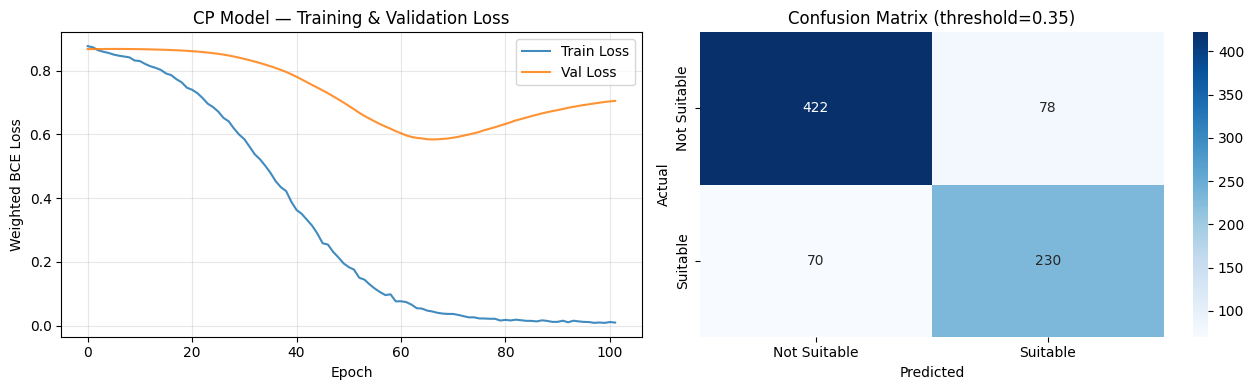

Plot saved as evaluation.png


In [41]:
preds_final = (val_probs >= best_thresh).astype(int)
actual      = y_test.values

acc  = accuracy_score(actual, preds_final)
prec = precision_score(actual, preds_final, zero_division=0)
rec  = recall_score(actual, preds_final, zero_division=0)
f1   = f1_score(actual, preds_final, zero_division=0)
mae  = mean_absolute_error(actual, val_probs)

print("=" * 50)
print("  MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}  (correct among recommended)")
print(f"  Recall    : {rec:.4f}  (suitable items caught)")
print(f"  F1-Score  : {f1:.4f}  (balance P & R)")
print(f"  MAE       : {mae:.4f}  (prob error)")
print("=" * 50)

# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, label='Train Loss', alpha=0.85)
axes[0].plot(val_losses,   label='Val Loss',   alpha=0.85)
axes[0].set_title('CP Model — Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Weighted BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

cm = confusion_matrix(actual, preds_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Suitable', 'Suitable'],
            yticklabels=['Not Suitable', 'Suitable'])
axes[1].set_title(f'Confusion Matrix (threshold={best_thresh:.2f})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved as evaluation.png")

## 🍽️ 13. Diet Plan Generator

**Features:**
- BMR → goal-based daily calorie & protein targets
- CP model scores all country-specific foods per meal
- **Diversity enforcement** — high / medium / low protein foods mixed
- **Unequal portions** `[38%, 35%, 27%]` — so quantities vary naturally
- Average over 10 sampled users — generalised (not user-specific) recommendation


In [ ]:
MEAL_CAL_RATIOS  = {"Breakfast": 0.25, "Lunch": 0.35, "Snack": 0.10, "Dinner": 0.30}
MEAL_PROT_RATIOS = {"Breakfast": 0.25, "Lunch": 0.35, "Snack": 0.05, "Dinner": 0.35}
CAL_WEIGHTS      = [0.38, 0.35, 0.27]   # unequal share per item → varied grams

def get_meal_score(food_row, country_id, goal_id, time_id):
    """Score one food item using the CP model, averaged over 10 users."""
    f_id  = food_to_id[food_row['food_name']]
    ctx   = encode_context(country_id, goal_id, time_id)
    p_rat = food_row['protein_g'] / (food_row['calories'] + 1)
    c_rat = food_row['carbs_g']   / (food_row['calories'] + 1)
    f_rat = food_row['fat_g']     / (food_row['calories'] + 1)

    nut_raw    = [[food_row['calories'], food_row['protein_g'], food_row['fat_g'],
                   food_row['carbs_g'], p_rat, c_rat, f_rat]]
    nut_scaled = torch.FloatTensor(scaler.transform(nut_raw))

    sample_uids = df_num['User_id'].drop_duplicates().sample(
        min(10, df_num['User_id'].nunique()), random_state=42
    ).tolist()

    scores = []
    for uid in sample_uids:
        s = model(torch.LongTensor([uid]), torch.LongTensor([f_id]),
                  torch.LongTensor([ctx]), nut_scaled).item()
        scores.append(s)
    return sum(scores) / len(scores)


def calculate_option(items, cal_target, prot_target):
    """Compute gram portions for 3 foods hitting cal + protein targets."""
    if len(items) < 3:
        return [], 0, 0

    result, total_prot, total_cal = [], 0, 0

    for idx, item in enumerate(items[:3]):
        item_cal_share  = cal_target  * CAL_WEIGHTS[idx]
        item_prot_share = prot_target * CAL_WEIGHTS[idx]

        grams_by_cal  = (item_cal_share  / item['cal_100'])  * 100
        grams_by_prot = (item_prot_share / item['prot_100']) * 100 \
                        if item['prot_100'] > 0 else grams_by_cal

        grams = (grams_by_cal + grams_by_prot) / 2
        grams = max(round(grams), 30)
        grams = min(grams, 400)

        prot = round((item['prot_100'] * grams) / 100)
        cal  = round((item['cal_100']  * grams) / 100)
        total_prot += prot
        total_cal  += cal

        result.append({'str': f"{grams}g {item['name']} ({prot}g P | {cal} kcal)",
                       'prot': prot, 'cal': cal})

    return result, total_prot, total_cal


def generate_diet_plan(weight, height, age, gender, goal, country_name):
    # BMR
    if gender.lower() == 'male':
        bmr = 10 * weight + 6.25 * height - 5 * age + 5
    else:
        bmr = 10 * weight + 6.25 * height - 5 * age - 161

    if goal not in goal_display_map:
        raise ValueError(f"Invalid goal. Choose from: {list(goal_display_map.keys())}")

    dataset_goal = goal_display_map[goal]

    if goal in ("Weight Gain", "Muscle Gain"):
        daily_cal, prot_factor = bmr + 500, 2.0
    elif goal == "Weight Loss":
        daily_cal, prot_factor = bmr - 500, 1.5
    else:
        daily_cal, prot_factor = bmr, 1.0

    total_protein = weight * prot_factor
    country_id    = country_to_id[country_name]
    goal_id       = goal_to_id[dataset_goal]
    candidates    = df_cat[df_cat['country'] == country_name].drop_duplicates('food_name')

    final_plan = {}
    model.eval()

    with torch.no_grad():
        for meal in ["Breakfast", "Lunch", "Snack", "Dinner"]:
            t_id             = time_to_id[meal]
            meal_cal_target  = daily_cal     * MEAL_CAL_RATIOS[meal]
            meal_prot_target = total_protein * MEAL_PROT_RATIOS[meal]
            meal_foods       = candidates[candidates['time_of_day'] == meal]

            meal_candidates = []
            for _, food in meal_foods.iterrows():
                score = get_meal_score(food, country_id, goal_id, t_id)
                meal_candidates.append({'name': food['food_name'], 'score': score,
                                        'cal_100': food['calories'], 'prot_100': food['protein_g']})

            # Diversity buckets
            high_p = sorted([x for x in meal_candidates if x['prot_100'] >= 15],
                            key=lambda x: x['score'], reverse=True)
            med_p  = sorted([x for x in meal_candidates if 5 <= x['prot_100'] < 15],
                            key=lambda x: x['score'], reverse=True)
            low_p  = sorted([x for x in meal_candidates if x['prot_100'] < 5],
                            key=lambda x: x['score'], reverse=True)
            all_s  = sorted(meal_candidates, key=lambda x: x['score'], reverse=True)

            # Option 1: best from each bucket
            opt1_pool, used1 = [], set()
            for pool in [high_p, med_p, low_p, all_s]:
                for item in pool:
                    if item['name'] not in used1:
                        opt1_pool.append(item); used1.add(item['name']); break
                if len(opt1_pool) == 3: break

            # Option 2: second-best, no overlap with Option 1
            opt2_pool, used2 = [], set(used1)
            for pool in [high_p, med_p, low_p, all_s]:
                for item in pool:
                    if item['name'] not in used2:
                        opt2_pool.append(item); used2.add(item['name']); break
                if len(opt2_pool) == 3: break

            # Fallback fill
            for pool in [opt1_pool, opt2_pool]:
                for item in all_s:
                    if len(pool) >= 3: break
                    if item['name'] not in {i['name'] for i in pool}: pool.append(item)

            opt1_items, opt1_prot, opt1_cal = calculate_option(opt1_pool[:3], meal_cal_target, meal_prot_target)
            opt2_items, opt2_prot, opt2_cal = calculate_option(opt2_pool[:3], meal_cal_target, meal_prot_target)

            final_plan[meal] = {
                "Option 1": opt1_items, "opt1_prot": opt1_prot, "opt1_cal": opt1_cal,
                "Option 2": opt2_items, "opt2_prot": opt2_prot, "opt2_cal": opt2_cal,
                "prot_target": round(meal_prot_target), "cal_target": round(meal_cal_target)
            }

    return final_plan, daily_cal, total_protein

print("Diet plan functions defined ✅")

Diet plan functions defined ✅


## 🚀 14. Generate Diet Plan — Example

In [43]:
# ── User Parameters — change these as needed ──────────────────
U_WEIGHT  = 75       # kg
U_HEIGHT  = 175      # cm
U_AGE     = 24
U_GENDER  = 'male'
U_GOAL    = 'Weight Gain'   # Options: Weight Gain / Weight Loss / Maintenance
U_COUNTRY = 'Saudi Arabia'      # Must match a country in the dataset
# ──────────────────────────────────────────────────────────────

plan, daily_cal, protein_target = generate_diet_plan(
    U_WEIGHT, U_HEIGHT, U_AGE, U_GENDER, U_GOAL, U_COUNTRY
)

print(f"{'='*62}")
print(f"  DIET PLAN — {U_COUNTRY}")
print(f"  Goal            : {U_GOAL}")
print(f"  Daily Calories  : {round(daily_cal)} kcal")
print(f"  Protein Target  : {round(protein_target)}g")
print(f"{'='*62}")

grand_prot, grand_cal = 0, 0

for meal in ["Breakfast", "Lunch", "Snack", "Dinner"]:
    data = plan[meal]
    print(f"\n  {meal.upper()} (Target: {data['prot_target']}g Protein | {data['cal_target']} kcal)")
    print(f"  {'-'*52}")

    for opt_key, prot_key, cal_key in [("Option 1","opt1_prot","opt1_cal"),
                                        ("Option 2","opt2_prot","opt2_cal")]:
        print(f"    [{opt_key}]")
        for item in data[opt_key]:
            print(f"      - {item['str']}")
        print(f"      ↳ Subtotal: {data[prot_key]}g Protein | {data[cal_key]} kcal")

    grand_prot += data["opt1_prot"]
    grand_cal  += data["opt1_cal"]

print(f"\n{'='*62}")
print(f"  📊 Grand Total (Option 1): {grand_prot}g Protein | {grand_cal} kcal")
print(f"  🎯 Target:                 {round(protein_target)}g Protein | {round(daily_cal)} kcal")
diff_p = grand_prot - round(protein_target)
diff_c = grand_cal  - round(daily_cal)
print(f"  📉 Difference:             {'+' if diff_p>=0 else ''}{diff_p}g Protein | {'+' if diff_c>=0 else ''}{diff_c} kcal")
print(f"{'='*62}")

  DIET PLAN — Saudi Arabia
  Goal            : Weight Gain
  Daily Calories  : 2229 kcal
  Protein Target  : 150g

  BREAKFAST (Target: 38g Protein | 557 kcal)
  ----------------------------------------------------
    [Option 1]
      - 67g Grilled Halloumi (14g P | 214 kcal)
      - 147g Labneh (Low Fat) (15g P | 176 kcal)
      - 280g Sukkari Dates (6g P | 784 kcal)
      ↳ Subtotal: 35g Protein | 1174 kcal
    [Option 2]
      - 181g Shakshuka (14g P | 208 kcal)
      - 400g Arabic Salad (4g P | 180 kcal)
      - 141g Foul Medames (10g P | 155 kcal)
      ↳ Subtotal: 28g Protein | 543 kcal

  LUNCH (Target: 52g Protein | 780 kcal)
  ----------------------------------------------------
    [Option 1]
      - 196g Steamed Shrimp (41g P | 196 kcal)
      - 234g Lentil Salad (19g P | 269 kcal)
      - 360g Okra Stew (Bamia) (11g P | 306 kcal)
      ↳ Subtotal: 71g Protein | 771 kcal
    [Option 2]
      - 140g Grilled Chicken Shish (34g P | 210 kcal)
      - 157g Chicken Kabsa (Skinles

## 💾 15. Save Model & Artifacts

In [44]:
torch.save(model.state_dict(), "cp_diet_model.pth")
joblib.dump(scaler,        "nutrient_scaler.save")
joblib.dump(best_thresh,   "best_threshold.save")
joblib.dump(goal_to_id,    "goal_to_id.save")
joblib.dump(country_to_id, "country_to_id.save")
joblib.dump(food_to_id,    "food_to_id.save")

print("Saved files:")
print("  ✅ cp_diet_model.pth")
print("  ✅ nutrient_scaler.save")
print("  ✅ best_threshold.save")
print("  ✅ goal_to_id.save")
print("  ✅ country_to_id.save")
print("  ✅ food_to_id.save")

Saved files:
  ✅ cp_diet_model.pth
  ✅ nutrient_scaler.save
  ✅ best_threshold.save
  ✅ goal_to_id.save
  ✅ country_to_id.save
  ✅ food_to_id.save


## 🔄 16. Load Model (Next Session)

In [ ]:
# Run this block in a fresh session to reload everything

# model = CPDietModel(N_USERS, N_FOODS, N_CONTEXTS, N_NUTRIENTS, rank=64)
# model.load_state_dict(torch.load('cp_diet_model.pth'))
# model.eval()

# scaler        = joblib.load('nutrient_scaler.save')
# best_thresh   = joblib.load('best_threshold.save')
# goal_to_id    = joblib.load('goal_to_id.save')
# country_to_id = joblib.load('country_to_id.save')
# food_to_id    = joblib.load('food_to_id.save')

print("Uncomment the lines above to load a saved model.")